In [2]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['text.usetex'] = True

from tensorflow.keras.datasets import mnist

import csv
import func

In [3]:
eigs = np.loadtxt('eig_train_small.csv', delimiter=',')
m_train = lambda ls: func.m_C(eigs, ls)

In [4]:
sig = lambda x: np.tanh(2*x)
g, g_prime, coeffs = func.gg(sig)

In [5]:
def mmse_qw(qw_init, v, Pv, alpha, gamma, Delta, m): 
    # v: set of values, Pv: masses at v, m: overlap function
    qw = np.copy(qw_init)
    for i in range(500):
        qw_old = qw.copy()
        mmse = g(1) - np.sum(Pv * v**2 * g(qw))
        rw = alpha/gamma * v**2 * g_prime(qw)/(Delta + mmse) 
        qw = m(rw) # 
        if np.max(np.abs(qw - qw_old))< 1e-9:
            break
    return mmse, qw

### Theory

In [6]:
gamma = 0.5
Delta = 0.1
n_point = 201
qw_init = np.array([1]*n_point)
v = np.linspace(-4, 4, n_point)
Pv = np.exp(-v**2/2)/np.sqrt(2*np.pi)
Pv /= np.sum(Pv)

# theory
alphas = np.linspace(0, 3, 201)
mmses = [mmse_qw(qw_init, v, Pv, alpha, gamma, Delta, m_train)[0] for alpha in alphas]

In [7]:
# experiment
alphas_ = [0.04, 0.125, 0.25, 0.375, 0.5, 2/3, 5/6, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75]
data_ = np.loadtxt('tanh_seed_1.csv', delimiter=',')
mmses_ = np.mean(data_, axis=0)
stds_ = np.std(data_, axis=0)

# alphas_1 = [1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75]
# data_1 = np.loadtxt('tanh_alpha_1_2.75.csv', delimiter=',')
# mmses_1 = np.mean(data_1, axis=0)
# stds_1 = np.std(data_1, axis=0)

# alphas_2 = [0.04, 0.125, 0.25, 0.375, 0.5, 2/3, 5/6]
# data_2 = np.loadtxt('tanh_alpha_less_1.csv', delimiter=',')
# mmses_2 = np.mean(data_2, axis=0)
# stds_2 = np.std(data_2, axis=0)

In [8]:
eigs_train = np.loadtxt('eig_train_small.csv', delimiter=',')
eigs_test = np.loadtxt('eig_test_small.csv', delimiter=',')

In [9]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = func.downsize_mnist(x_train)
mean_train = x_train.mean(axis=0)
x_train = x_train - mean_train

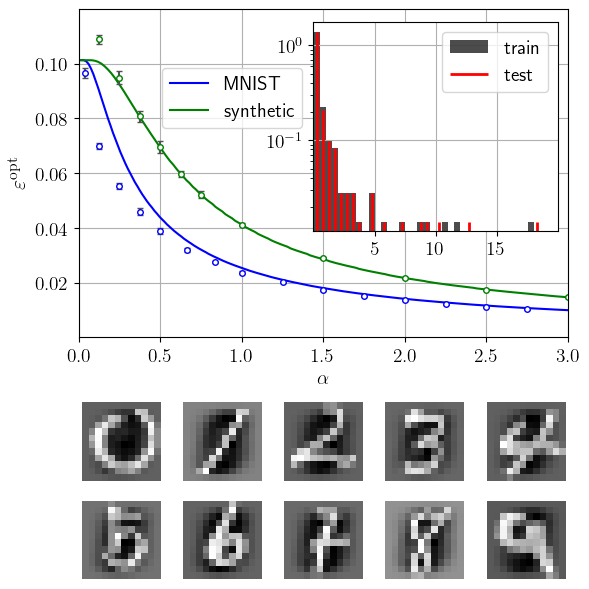

In [23]:
width, height = 6, 6
size = int(width*2.4)

fig = plt.figure(figsize=(width, height), tight_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[3.9, 2.1])

ax = fig.add_subplot(gs[0])
ax.set_xlim(0, 3)
ax.tick_params(axis='both', labelsize=size)
ax.tick_params(axis='both', labelsize=size)
ax.set_xlabel(r'$\alpha$', fontsize=size)
ax.set_ylabel(r'$\varepsilon^{\rm opt}$', fontsize=int(1.2*size))
ax.set_ylim(0, 0.12)
ax.grid()

x1, x2 = 1/2-0.02, 4/11-0.04
inset_ax = ax.inset_axes([x1, x2, 1-x1-0.02, 1-x2-0.04]) 
inset_ax.tick_params(axis='both', labelsize=size)
inset_ax.tick_params(axis='both', labelsize=size)
inset_ax.set_xticks([5, 10, 15])
inset_ax.set_yticks([0.5, 1, 1.5])
inset_ax.grid()
inset_ax.set_xlim(0, 20)


bins = np.linspace(0, 20, 41)
counts_train, _ = np.histogram(eigs_train, bins=bins, density=True)
inset_ax.hist(eigs_train, bins=bins, density=True, facecolor='black', label='train', alpha=0.7)

bin_centers = 0.5 * (bins[:-1] + bins[1:])
counts_test, _ = np.histogram(eigs_test, bins=bins, density=True)
for x, y in zip(bin_centers, counts_test):
    inset_ax.vlines(x, 0, y, colors='red', lw=2, label='test' if x == bin_centers[0] else "")

inset_ax.legend(fontsize=size)
inset_ax.set_yscale('log')


mmses_0_relu = np.loadtxt('sig0_relu_theory.csv', delimiter=',')
data_relu = np.loadtxt('v_gauss_sig0_relu.csv', delimiter=',')
mmses_relu_ex = np.mean(data_relu, axis=0)
stds_relu = np.std(data_relu, axis=0)

'''
MNIST
'''
ax.plot(alphas, mmses, color='blue', label='MNIST')
ax.errorbar(alphas_, mmses_, stds_, fmt='o', markersize=4, markerfacecolor='white', markeredgecolor='blue', capsize=2, color='blue', ecolor='#505050')



'''
relu
'''
alphas_relu = np.linspace(0, 4, 201)
alphas_relu_ex = [1/8, 2/8, 3/8, 4/8, 5/8, 6/8, 1, 1.5, 2, 2.5, 3, 3.5, 4]
ax.plot(alphas_relu, mmses_0_relu, color='green', label='synthetic')
ax.errorbar(alphas_relu_ex, mmses_relu_ex, stds_relu, fmt='o', markersize=4, markerfacecolor='white', markeredgecolor='green', capsize=2, color='red', ecolor='#505050')
ax.set_yticks([0.02, 0.04, 0.06, 0.08, 0.1])
ax.legend(loc='upper left', bbox_to_anchor=(0.15, 0.85), fontsize=size)


'''
digits
'''
sub_gs = gs[1].subgridspec(2, 5)
axes = np.empty((2, 5), dtype=object)
for digit in range(10):
    axes[digit//5, digit%5] = fig.add_subplot(sub_gs[digit//5, digit%5])
    idx = np.random.choice(np.where(y_train == digit)[0])
    axes[digit//5, digit%5].imshow(x_train[idx], cmap='gray')
    axes[digit//5, digit%5].axis('off')

plt.savefig('mmse_real_data.pdf')
plt.show()